# Demo Nuova API — Mobility Book Style

Questo notebook dimostra l'uso della libreria `mobility_book_style` con la nuova API semplificata.

## 📦 Installazione

### Opzione 1: All'interno del Notebook (consigliato)
Esegui le celle nella sezione "0. Verifica Ambiente" qui sotto. Installeranno automaticamente il pacchetto nel kernel Python corrente.

### Opzione 2: Da Terminale

```bash
# Naviga alla root del progetto
cd /path/to/mobility-book-graphic-style-guide

# Installa in modalità sviluppo
pip install -e .

# oppure con dipendenze complete
pip install -e ".[all]"
```

### Opzione 3: Dopo la Pubblicazione (futuro)

```bash
pip install mobility-book-style[all]
```

## ⚠️ Nota sui Kernel Jupyter

Se ottieni `ModuleNotFoundError`, significa che il kernel Jupyter sta usando un ambiente Python diverso da quello dove hai installato il pacchetto. Usa l'**Opzione 1** qui sopra per risolvere automaticamente.

## 1. Setup

In [1]:
# Installa il pacchetto nel kernel corrente (esegui questa cella una sola volta)
import sys
import subprocess
from pathlib import Path

# Trova la root del progetto
notebook_dir = Path.cwd()
project_root = notebook_dir.parent

print(f"📍 Notebook directory: {notebook_dir}")
print(f"📁 Project root: {project_root}")
print(f"🐍 Python executable: {sys.executable}")
print(f"🐍 Python version: {sys.version.split()[0]}")

# Installa in modalità editable
print(f"\n📦 Installazione mobility-book-style...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", str(project_root)],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("✅ Installazione completata con successo!")
    print("\n⚠️  Potrebbe essere necessario riavviare il kernel:")
    print("   Kernel → Restart Kernel")
else:
    print("❌ Errore durante l'installazione:")
    print(result.stderr)

📍 Notebook directory: /Users/dfadda/Git/mobility-book-graphic-style-guide/examples
📁 Project root: /Users/dfadda/Git/mobility-book-graphic-style-guide
🐍 Python executable: /Users/dfadda/Git/mobility-book-graphic-style-guide/.venv/bin/python
🐍 Python version: 3.10.11

📦 Installazione mobility-book-style...
✅ Installazione completata con successo!

⚠️  Potrebbe essere necessario riavviare il kernel:
   Kernel → Restart Kernel
✅ Installazione completata con successo!

⚠️  Potrebbe essere necessario riavviare il kernel:
   Kernel → Restart Kernel


In [2]:
# Verifica che l'installazione sia andata a buon fine
try:
    import mobility_book_style as mbs
    print(f"✅ mobility_book_style v{mbs.__version__} importato correttamente!")
    print(f"📦 Funzioni disponibili: {', '.join(mbs.__all__)}")
except ImportError as e:
    print(f"❌ Errore di import: {e}")
    print("\n🔧 Soluzioni:")
    print("   1. Esegui la cella precedente per installare il pacchetto")
    print("   2. Riavvia il kernel: Kernel → Restart Kernel")
    print("   3. Verifica di essere nella directory corretta")

✅ mobility_book_style v0.1.0 importato correttamente!
📦 Funzioni disponibili: token, apply_matplotlib_theme, style_table, enable_altair_theme, disable_altair_theme, export_ase, export_colors_dict


## 0. Verifica Ambiente

**Importante**: Prima di eseguire questo notebook, assicurati che il pacchetto sia installato nell'ambiente Python usato da Jupyter.

```bash
# Opzione 1: Installa nel kernel corrente (esegui la cella successiva)
# Opzione 2: Installa da terminale nell'ambiente anaconda
# conda activate base  # o il tuo environment
# cd /path/to/mobility-book-graphic-style-guide
# pip install -e .
```

In [3]:
from pathlib import Path

# Crea cartella output
OUT = Path("outputs")
OUT.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUT.absolute()}")

Output directory: /Users/dfadda/Git/mobility-book-graphic-style-guide/examples/outputs


## 2. Test Matplotlib con Nuova API

Matplotlib is building the font cache; this may take a moment.


✅ Salvato: outputs/matplotlib_new_api.png


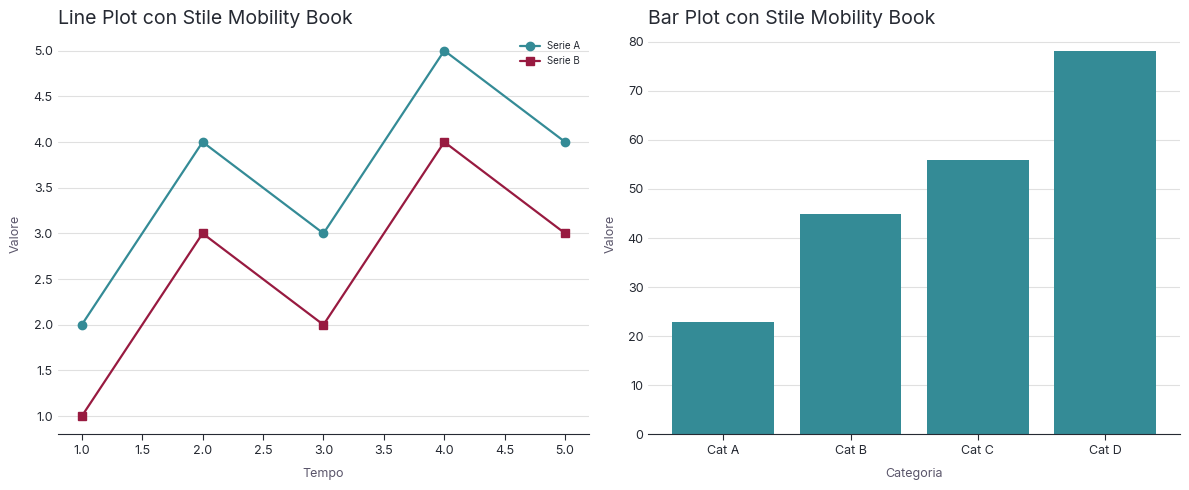

In [4]:
import mobility_book_style as mbs
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Applica il tema (semplice!)
mbs.apply_matplotlib_theme()

# Crea un grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: Line plot
ax1.plot([1, 2, 3, 4, 5], [2, 4, 3, 5, 4], label='Serie A', marker='o')
ax1.plot([1, 2, 3, 4, 5], [1, 3, 2, 4, 3], label='Serie B', marker='s')
ax1.set_title('Line Plot con Stile Mobility Book')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Valore')
ax1.legend()
ax1.grid(True, axis='y')

# Grafico 2: Bar plot
categories = ['Cat A', 'Cat B', 'Cat C', 'Cat D']
values = [23, 45, 56, 78]
ax2.bar(categories, values)
ax2.set_title('Bar Plot con Stile Mobility Book')
ax2.set_xlabel('Categoria')
ax2.set_ylabel('Valore')
ax2.grid(True, axis='y')

plt.tight_layout()

# Salva
output_path = OUT / 'matplotlib_new_api.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Salvato: {output_path}")

plt.show()


📏 Dimensioni standard figure (da design tokens):
   Larghezza: 310pt = 4.31 inches
   Altezza: 230pt = 3.19 inches

✅ Salvato: outputs/matplotlib_token_size.png
   Dimensioni figura: 8.61 × 3.19 inches


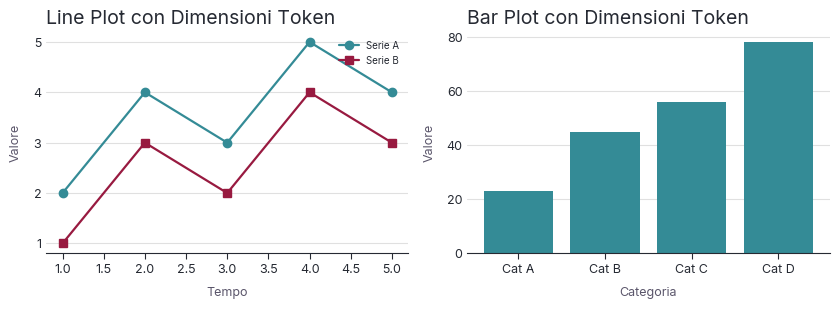

In [5]:
# Usa le dimensioni dai design tokens per la figura
from mobility_book_style.utils import to_inches
from mobility_book_style._tokens import token

# Ottieni le dimensioni dai token e converti in inches
fig_width = to_inches(token.component.figure.default.width)
fig_height = to_inches(token.component.figure.default.height)

print(f"📏 Dimensioni standard figure (da design tokens):")
print(f"   Larghezza: {token.component.figure.default.width} = {fig_width:.2f} inches")
print(f"   Altezza: {token.component.figure.default.height} = {fig_height:.2f} inches")

# Per 2 subplot affiancati, raddoppia la larghezza
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width * 2, fig_height))

# Grafico 1: Line plot
ax1.plot([1, 2, 3, 4, 5], [2, 4, 3, 5, 4], label='Serie A', marker='o')
ax1.plot([1, 2, 3, 4, 5], [1, 3, 2, 4, 3], label='Serie B', marker='s')
ax1.set_title('Line Plot con Dimensioni Token')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Valore')
ax1.legend()
ax1.grid(True, axis='y')

# Grafico 2: Bar plot
categories = ['Cat A', 'Cat B', 'Cat C', 'Cat D']
values = [23, 45, 56, 78]
ax2.bar(categories, values)
ax2.set_title('Bar Plot con Dimensioni Token')
ax2.set_xlabel('Categoria')
ax2.set_ylabel('Valore')
ax2.grid(True, axis='y')

plt.tight_layout()

# Salva
output_path = OUT / 'matplotlib_token_size.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Salvato: {output_path}")
print(f"   Dimensioni figura: {fig_width * 2:.2f} × {fig_height:.2f} inches")

plt.show()


✅ Salvato: outputs/matplotlib_token_size.png
   Dimensioni figura: 4.31 × 2.42 inches


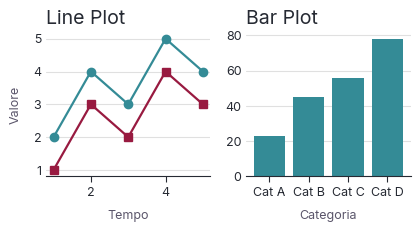

In [6]:
# Vorrei un plot affiancato come il precedente, dove però la larghezza totale corrisponde a token.component.figure.default.width e i due plot sono la metà ciascuno
from mobility_book_style.utils import to_inches
from mobility_book_style._tokens import token
# Ottieni le dimensioni dai token e converti in inches
fig_width = to_inches(token.component.figure.default.width) / 2
fig_height = to_inches(token.component.figure.default.width) *9/16


# Per 2 subplot affiancati, raddoppia la larghezza
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width * 2, fig_height))

# Grafico 1: Line plot
ax1.plot([1, 2, 3, 4, 5], [2, 4, 3, 5, 4], label='Serie A', marker='o')
ax1.plot([1, 2, 3, 4, 5], [1, 3, 2, 4, 3], label='Serie B', marker='s')
ax1.set_title('Line Plot')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Valore')
ax1.grid(True, axis='y')

# Grafico 2: Bar plot
categories = ['Cat A', 'Cat B', 'Cat C', 'Cat D']
values = [23, 45, 56, 78]
ax2.bar(categories, values)
ax2.set_title('Bar Plot ')
ax2.set_xlabel('Categoria')
ax2.grid(True, axis='y')

plt.tight_layout()

# Salva
output_path = OUT / 'matplotlib_token_size.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Salvato: {output_path}")
print(f"   Dimensioni figura: {fig_width * 2:.2f} × {fig_height:.2f} inches")

plt.show()

/var/folders/wn/b7bbzbgx3w1d40tvs_lzk1cr0000gn/T/ipykernel_89707/1089540113.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


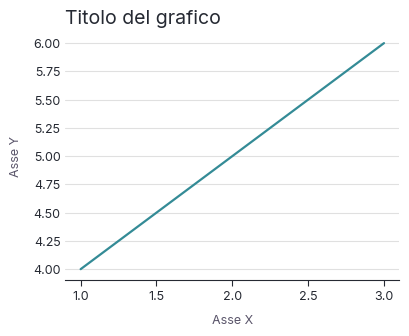

In [7]:
# grafico minimo senza nessuna personalizzazione, solo titolo e nome assi
fig_width = to_inches(token.component.figure.default.width)
fig, ax = plt.subplots(figsize=(fig_width, fig_width * 3/4))

ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("Titolo del grafico")
ax.set_xlabel("Asse X")
ax.set_ylabel("Asse Y")
fig.show()

/var/folders/wn/b7bbzbgx3w1d40tvs_lzk1cr0000gn/T/ipykernel_89707/3310366585.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/wn/b7bbzbgx3w1d40tvs_lzk1cr0000gn/T/ipykernel_89707/3310366585.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


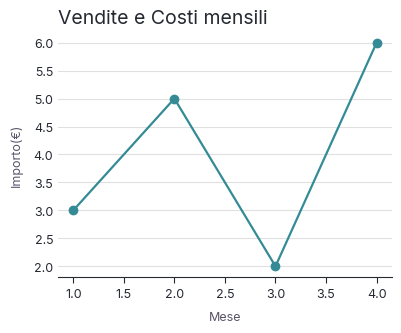

In [ ]:
# # Crea il tuo grafico
# fig_width = to_inches(token.component.figure.default.width)
# fig, ax = plt.subplots(figsize=(fig_width, fig_width * 3/4))
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [3, 5, 2, 6], marker='o')
ax.set_title('Vendite e Costi Mensili')
ax.set_xlabel('Mese')
ax.set_ylabel('Importo(€)')
ax.legend()
fig.show()

In [9]:
# stesso grafico di sopra ma in altair
import altair as alt
import pandas as pd

mbs.enable_altair_theme()

data = pd.DataFrame({
    'Mese': [1, 2, 3, 4],
    'Importo': [3, 5, 2, 6]
})
chart = alt.Chart(data).mark_line(point=True).encode(
    x=alt.X('Mese', type='ordinal', title='Mese'),
    y=alt.Y('Importo', title='Importo(€)' ),
).properties(
    title='Vendite e Costi Mensili',
)
chart

alt.Chart(...)

## 4. Test Altair con Nuova API

In [10]:
import altair as alt
import pandas as pd

# Abilita il tema (semplice!)
mbs.enable_altair_theme()

# Dati di esempio
data = pd.DataFrame({
    'Mese': ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu'],
    'Vendite': [120, 135, 148, 162, 178, 195],
    'Costi': [80, 85, 90, 95, 100, 105]
})

# Reshape per Altair
data_long = data.melt('Mese', var_name='Tipo', value_name='Valore')

# Crea il grafico
chart = alt.Chart(data_long).mark_line(point=True).encode(
    x=alt.X('Mese:N', title='Mese'),
    y=alt.Y('Valore:Q', title='Importo (€)'),
    color=alt.Color('Tipo:N', title='Categoria'),
    tooltip=['Mese', 'Tipo', 'Valore']
).properties(
    title='Vendite e Costi Mensili',
    width=413,
    height=306,
)
# Salva
html_path = OUT / 'altair_new_api.html'
chart.save(str(html_path))
print(f"✅ Salvato HTML: {html_path}")

# Salva PNG (se vl-convert è installato)
try:
    png_path = OUT / 'altair_new_api.png'
    chart.save(str(png_path), scale_factor=2)
    print(f"✅ Salvato PNG: {png_path}")
    from IPython.display import Image, display
    display(Image(filename=str(png_path)))
except Exception as e:
    print(f"⚠️  PNG export fallito: {e}")
    print("Installa vl-convert-python per esportare PNG")

# Display inline
chart

✅ Salvato HTML: outputs/altair_new_api.html
⚠️  PNG export fallito: Saving charts in 'png' format requires the vl-convert-python package: see https://altair-viz.github.io/user_guide/saving_charts.html#png-svg-and-pdf-format
Installa vl-convert-python per esportare PNG


alt.Chart(...)

## 5. Bar Chart Altair

In [11]:
# Dati per bar chart
# Abilita il tema (semplice!)
mbs.enable_altair_theme()

cities = pd.DataFrame({
    'Città': ['Milano', 'Roma', 'Napoli', 'Torino', 'Palermo'],
    'Popolazione': [1396, 2860, 962, 871, 674]
})

bar_chart = alt.Chart(cities).mark_bar().encode(
    x=alt.X('Città:N', sort='-y', title='Città'),
    y=alt.Y('Popolazione:Q', title='Popolazione (migliaia)'),
    color=alt.Color('Città:N'),
    tooltip=['Città', 'Popolazione']
).properties(
    title='Popolazione delle Principali Città Italiane',
)

bar_chart

alt.Chart(...)

## 3. Test Tabella Matplotlib

✅ Salvato: outputs/matplotlib_table_new_api.png


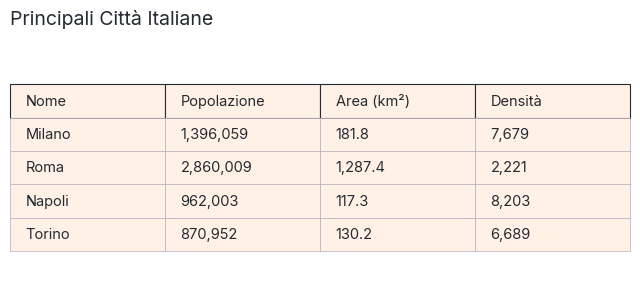

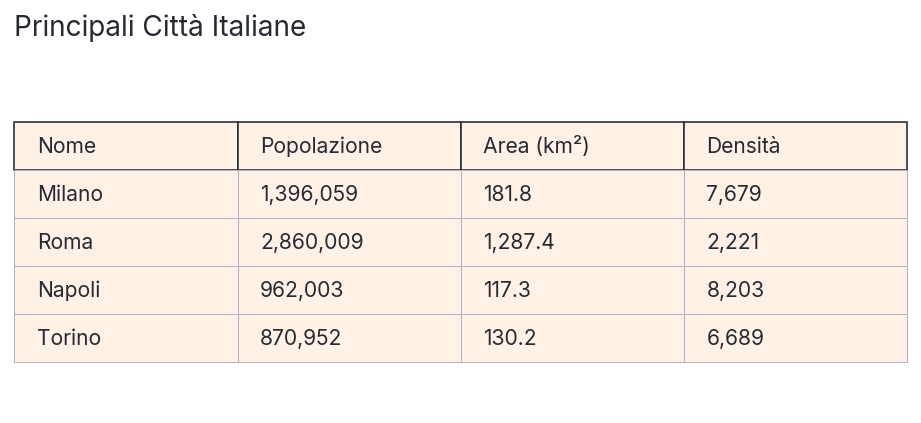

In [12]:
# Tabella stilizzata
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

data = [
    ['Nome', 'Popolazione', 'Area (km²)', 'Densità'],
    ['Milano', '1,396,059', '181.8', '7,679'],
    ['Roma', '2,860,009', '1,287.4', '2,221'],
    ['Napoli', '962,003', '117.3', '8,203'],
    ['Torino', '870,952', '130.2', '6,689'],
]

table = ax.table(
    cellText=data,
    loc='center',
    cellLoc='left',
    colWidths=[0.25, 0.25, 0.25, 0.25]
)

# Applica lo stile (semplice!)
mbs.style_table(table)

table.auto_set_font_size(False)
table.scale(1, 2)

plt.title('Principali Città Italiane', pad=20, fontsize=14, fontweight='bold')

output_path = OUT / 'matplotlib_table_new_api.png'
plt.savefig(output_path, dpi=144, bbox_inches='tight')
print(f"✅ Salvato: {output_path}")

plt.show()
display(Image(filename=str(output_path)))

## 6. Verifica Info Tema

In [13]:
import matplotlib as mpl

print("=" * 60)
print("INFO TEMA APPLICATO")
print("=" * 60)

print("\n📦 Libreria: mobility_book_style")
print(f"   Versione: {mbs.__version__}")

print("\n🎨 Matplotlib:")
print(f"   Font family: {mpl.rcParams.get('font.sans-serif')[:3]}")
print(f"   Background: {mpl.rcParams.get('figure.facecolor')}")
print(f"   Text color: {mpl.rcParams.get('text.color')}")
print(f"   Line width: {mpl.rcParams.get('lines.linewidth')}")

print("\n🎨 Altair:")
print(f"   Tema attivo: {alt.themes.active}")
print(f"   Temi disponibili: {alt.themes.names()[:5]}...")

print("\n📁 Output generati:")
for p in sorted(OUT.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"   - {p.name} ({size_kb:.1f} KB)")

print("\n✅ Test completato con successo!")

INFO TEMA APPLICATO

📦 Libreria: mobility_book_style
   Versione: 0.1.0

🎨 Matplotlib:
   Font family: ['Inter', 'sans-serif']
   Background: #ffffff
   Text color: #262A33
   Line width: 1.6

🎨 Altair:
   Tema attivo: mobility_theme
   Temi disponibili: ['carbong10', 'carbong100', 'carbong90', 'carbonwhite', 'dark']...

📁 Output generati:
   - altair_new_api.html (4.0 KB)
   - matplotlib_new_api.png (192.8 KB)
   - matplotlib_table_new_api.png (38.0 KB)
   - matplotlib_token_size.png (64.5 KB)
   - mobility_book_swatches.ase (9.8 KB)

✅ Test completato con successo!


## 7. Disabilita Tema Altair (Opzionale)

In [14]:
# Torna al tema default di Altair
mbs.disable_altair_theme()

print(f"Tema Altair corrente: {alt.themes.active}")

# Test con tema default
test_chart = alt.Chart(cities).mark_bar().encode(
    x='Città:N',
    y='Popolazione:Q'
).properties(title='Grafico con tema DEFAULT Altair', width=400, height=200)

test_chart

Tema Altair corrente: default


alt.Chart(...)

---

## 🎉 Conclusioni

La nuova API è:

- ✅ **Semplice**: solo 2-3 funzioni da ricordare
- ✅ **Pulita**: import come `mobility_book_style as mbs`
- ✅ **Consistente**: stesso stile per Matplotlib e Altair
- ✅ **Immutabile**: lo stile non può essere modificato dall'utente

### Uso Tipico

```python
import mobility_book_style as mbs

# Matplotlib
mbs.apply_matplotlib_theme()

# Altair
mbs.enable_altair_theme()
```

Fine! 🚀

---

## 🎨 Export Swatches per Adobe Illustrator

In [15]:
import mobility_book_style as mbs
from pathlib import Path

# Export colors to Adobe Swatch Exchange (.ase)
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

ase_path = output_dir / "mobility_book_swatches.ase"
mbs.export_ase(str(ase_path), include_base=True)

print(f"✅ Swatches esportati in: {ase_path}")
print(f"📦 File size: {ase_path.stat().st_size / 1024:.2f} KB")

# Ottieni i colori come dizionario risolto
colors_dict = mbs.export_colors_dict()

print("\n🎨 Colori disponibili:")
print(f"  - {len(colors_dict['color_flat'])} token colore totali (flat)")
print(f"  - {len(colors_dict['categorical_palette'])} colori categoriali")
print(f"  - {len(colors_dict['divergent_palette'])} colori divergenti")

print("\n📋 Esempi di token:")
print(f"  brand.primary     {colors_dict['color']['brand']['primary']}")
print(f"  text.secondary    {colors_dict['color']['text']['secondary']}")
print(f"  background.alt    {colors_dict['color']['background']['alternative']}")

print("\n📋 Palette categoriale (prime 5):")
for i, hex_code in enumerate(colors_dict['categorical_palette']):
    if i < 5:
        print(f"  {i+1:02d}: {hex_code}")
    elif i == 5:
        print(f"  ... ({len(colors_dict['categorical_palette']) - 5} altri)")
        break

✅ Swatches esportati in: outputs/mobility_book_swatches.ase
📦 File size: 9.84 KB

🎨 Colori disponibili:
  - 112 token colore totali (flat)
  - 7 colori categoriali
  - 11 colori divergenti

📋 Esempi di token:
  brand.primary     #348b96
  text.secondary    #5b566b
  background.alt    #fff1e6

📋 Palette categoriale (prime 5):
  01: #348b96
  02: #981a40
  03: #534e93
  04: #a0a369
  05: #d5aa00
  ... (2 altri)


Il file `.ase` può essere importato direttamente in Adobe Illustrator:
1. In Illustrator, apri il pannello **Campioni** (Window > Swatches)
2. Dal menu del pannello, seleziona **Open Swatch Library > Other Library...**
3. Seleziona il file `mobility_book_swatches.ase`

Tutti i colori del brand saranno disponibili nel pannello Campioni! 🎨